<a href="https://colab.research.google.com/github/kashishkumar2005/MLLab/blob/main/LAB_5_(ML).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import precision_recall_curve, roc_curve

In [ ]:
# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# features and target
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable info
print(breast_cancer_wisconsin_diagnostic.variables)

print(X.head())
print("Dataset shape:", X.shape)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

In [ ]:
y = y.replace({'B':0, 'M':1})

/tmp/ipykernel_329/905732119.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = y.replace({'B':0, 'M':1})


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (455, 30)
Testing data shape: (114, 30)


# Experiment-1 (Naive Bayes)

In [ ]:
#Train Model
nb = GaussianNB()

nb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


GaussianNB()

In [ ]:
#Predict Test Data
nb_pred = nb.predict(X_test)

In [ ]:
#Evaluate Model
# 1. Accuracy
print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

Naive Bayes Accuracy: 0.9649122807017544


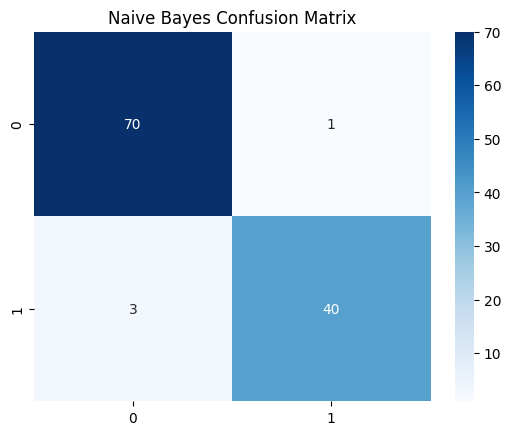

In [ ]:
# 2. Confusion Matrix
cm_nb = confusion_matrix(y_test, nb_pred)

sns.heatmap(cm_nb, annot=True, cmap="Blues")
plt.title("Naive Bayes Confusion Matrix")
plt.show()

In [ ]:
# 3. Classification Report
print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        71
           1       0.98      0.93      0.95        43

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



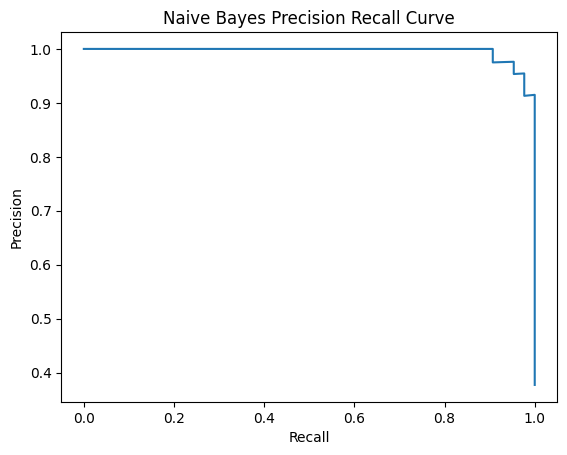

In [ ]:
# 4. Precision Recall Curve
y_prob_nb = nb.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_prob_nb)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Naive Bayes Precision Recall Curve")
plt.show()

# Experiment-2 (Decision Tree)

In [ ]:
#Train Model
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
#Predict Test Data
dt_pred = dt.predict(X_test)

In [ ]:
#Evaluate Model
# 1. Accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9473684210526315


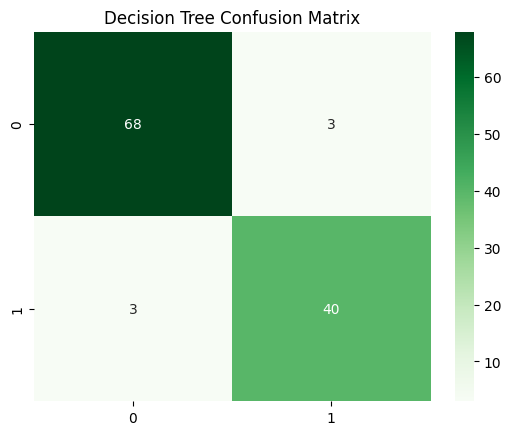

In [ ]:
# 2. Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm_dt, annot=True, cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [ ]:
# 3. Classification Report
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96        71
           1       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



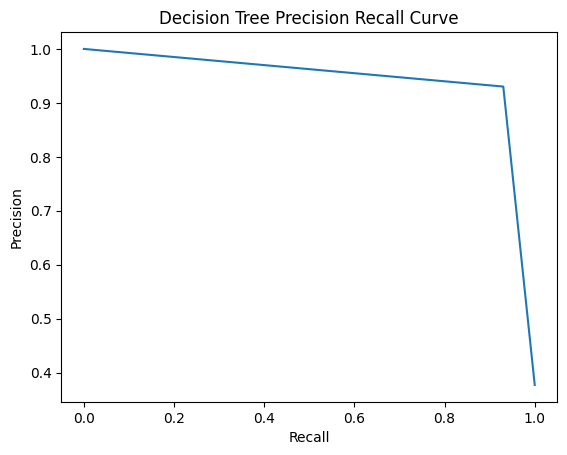

In [ ]:
# 4. Precision Recall Curve
y_prob_dt = dt.predict_proba(X_test)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_prob_dt)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Decision Tree Precision Recall Curve")
plt.show()

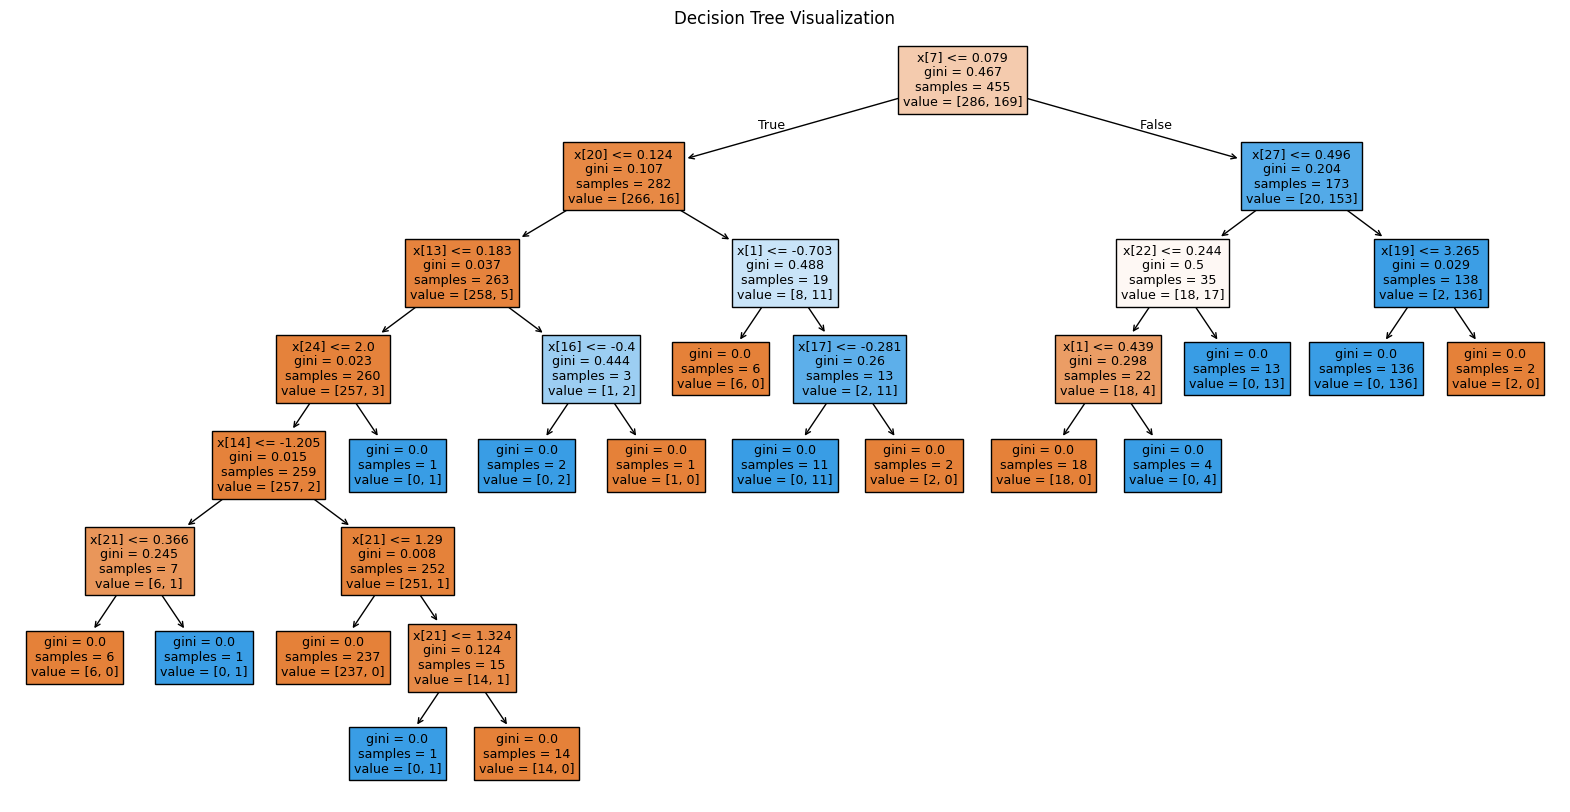

In [ ]:
# 4. Visualize Decision Tree
plt.figure(figsize=(20,10))
plot_tree(dt, filled=True)
plt.title("Decision Tree Visualization")
plt.show()

# Experiment-3 (Model Comparison)

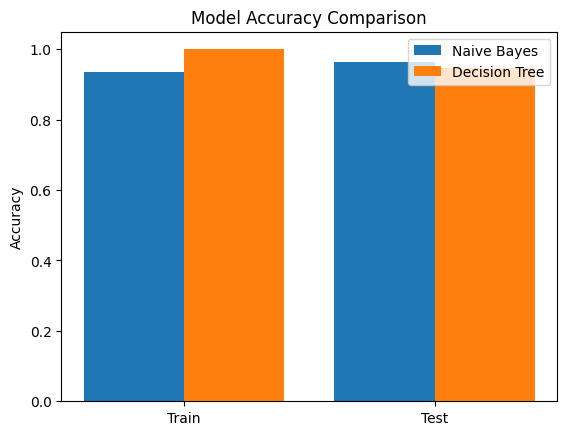

In [ ]:
#Accuracy Comparison Bar Chart
train_nb = nb.score(X_train, y_train)
test_nb = nb.score(X_test, y_test)

train_dt = dt.score(X_train, y_train)
test_dt = dt.score(X_test, y_test)

labels = ["Train", "Test"]

nb_scores = [train_nb, test_nb]
dt_scores = [train_dt, test_dt]

x = np.arange(len(labels))

plt.bar(x-0.2, nb_scores, 0.4, label="Naive Bayes")
plt.bar(x+0.2, dt_scores, 0.4, label="Decision Tree")

plt.xticks(x, labels)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")

plt.legend()
plt.show()

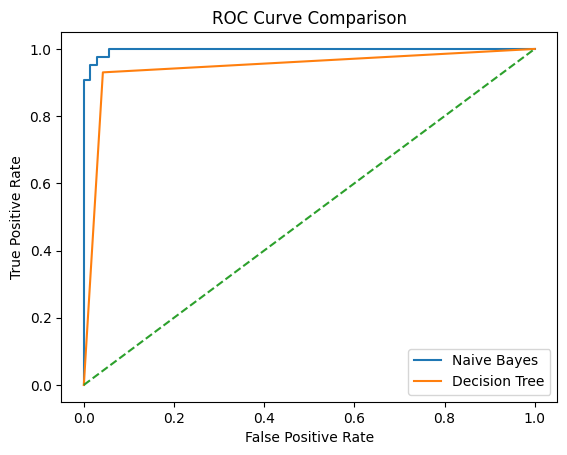

In [ ]:
#ROC Curve Comparison
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.plot(fpr_nb, tpr_nb, label="Naive Bayes")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

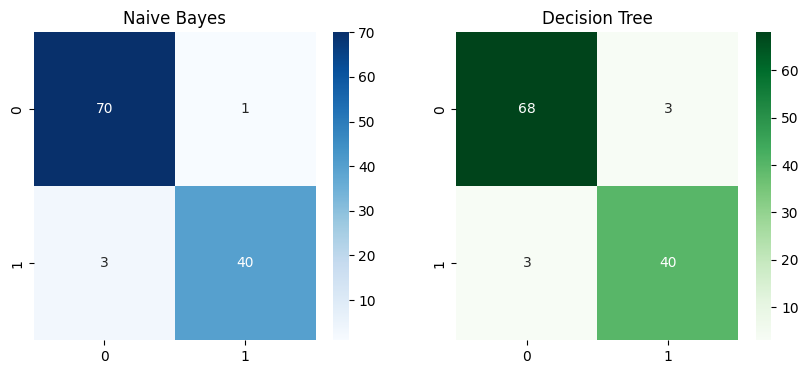

In [ ]:
#Confusion Matrix Comparison
fig, ax = plt.subplots(1,2, figsize=(10,4))

sns.heatmap(cm_nb, annot=True, ax=ax[0], cmap="Blues")
ax[0].set_title("Naive Bayes")

sns.heatmap(cm_dt, annot=True, ax=ax[1], cmap="Greens")
ax[1].set_title("Decision Tree")

plt.show()